In [1]:
import numpy as np
from datascience import *
def best_choice_random():
    x = np.random.choice(np.arange(1,7))
    if x <= 2:
        return -1
    elif x <= 4:
        return 0
    else:
        return 1
a = make_array()
for i in range(5):
    a = np.append(a,best_choice_random())
a

array([ 0.,  0.,  1.,  0., -1.])

Simulation

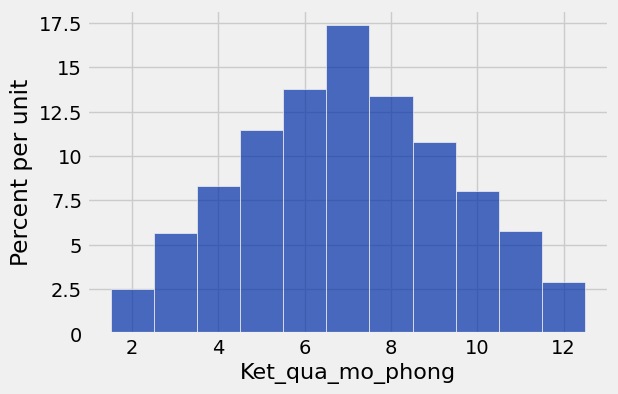

In [2]:
import matplotlib.pyplot as plots
%matplotlib inline
plots.style.use("fivethirtyeight")
def one_simulation():
    die = np.arange(1,7)
    return sum(np.random.choice(die,2))

nums_repition = 10000

result = make_array()

for i in range(nums_repition):
    x = one_simulation()
    result = np.append(result, x)
    
tab = Table().with_columns(
    'So_lan_mo_phong' , np.arange(1,nums_repition+1),
    'Ket_qua_mo_phong' , result
)

tab.hist('Ket_qua_mo_phong',bins = np.arange(1.5, 12.6, 1))

## 1. Mo phong monty hall
Mot tro choi trong do co 3 canh cua gom 2 cua la hai con de mot cua co xe hoi. Nguoi choi xe chon mot cua, Monty hall se tiet lo mot cua co con de nguoi choi se phai chon xem giu lai cua minh dang chon hay la chon cua con lai 

In [3]:
from datascience import *
import numpy as np

def other_goat(goat):
    if goat == '1 goat':
        return '2 goat'
    elif goat == '2 goat':
        return '1 goat'

def one_simulation():
    monty_hall =make_array('1 goat', '2 goat', 'car')
    choice  =  np.random.choice(monty_hall)
    if choice  == '1 goat':
        return ['1 goat','2 goat','car']
    elif choice == '2 goat':
        return ['2 goat','1 goat','car']
    else:
        revealed = np.random.choice(make_array('1 goat','2 goat'))
        return [choice,revealed,other_goat(revealed)]
    
one_simulation()

['1 goat', '2 goat', 'car']

In [11]:
repition = 10000
result = Table(['Guess','Revealed','Remain'])

for i in np.arange(repition):
    value  = one_simulation()
    result.append(value)
result
    
    

Guess,Revealed,Remain
car,2 goat,1 goat
2 goat,1 goat,car
1 goat,2 goat,car
2 goat,1 goat,car
car,1 goat,2 goat
1 goat,2 goat,car
1 goat,2 goat,car
2 goat,1 goat,car
car,1 goat,2 goat
car,1 goat,2 goat


xac suat xe nam o lua chon dau

In [12]:
first_choice =result.group('Guess')
first_choice

Guess,count
1 goat,3281
2 goat,3358
car,3361


xac suat xe nam o canh cua cuoi cung

In [13]:
last_choice = result.group('Remain')
last_choice

Remain,count
1 goat,1739
2 goat,1622
car,6639


In [18]:
joined = first_choice.join('Guess', last_choice,'Remain')
joined

Guess,count,count_2
1 goat,3281,1739
2 goat,3358,1622
car,3361,6639


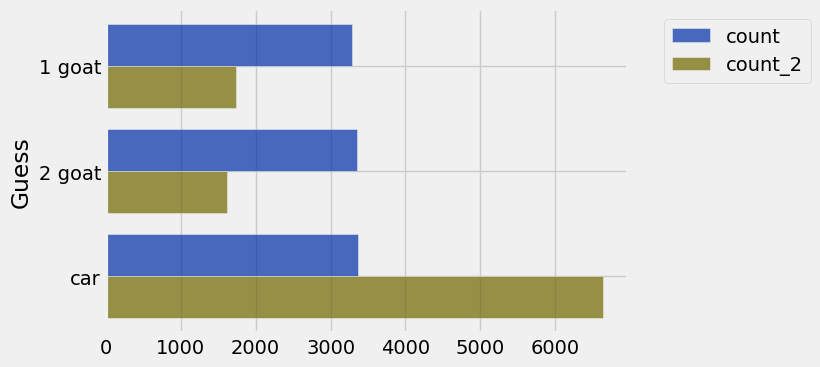

In [19]:
import matplotlib.pyplot as plots
%matplotlib inline
plots.style.use('fivethirtyeight')

joined.barh('Guess')